In [1]:
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import ClippedAdam, Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

import time

c:\Users\kgl07\anaconda3\envs\course42186\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set random seed for reproducibility
pyro.set_rng_seed(42)

In [3]:
# load the data
test_data_path = "small_test_data.csv"
test_label_path = "small_test_labels.csv"
test_data = pd.read_csv(test_data_path).values.astype(np.float32)
test_label = pd.read_csv(test_label_path).values

val_data_path = "small_val_data.csv"
val_label_path = "small_val_labels.csv"
val_data = pd.read_csv(val_data_path).values.astype(np.float32)
val_label = pd.read_csv(val_label_path).values

print("test_data shape:", test_data.shape)
print("test_label shape:", test_label.shape)

print(test_data[0,0:10])

test_data shape: (200, 400)
test_label shape: (200, 1)
[5.53000e-02 0.00000e+00 5.55492e+01 4.71580e+00 3.67360e+00 2.70879e+01
 1.88500e-01 1.50104e+01 1.45420e+01 1.54886e+01]


In [4]:
X_train = test_data


# Z-score normalization per gene
X_train_mean = X_train.mean(axis=0)
X_train_std = X_train.std(axis=0) + 1e-6  # avoid div-by-zero
X_norm = (X_train - X_train_mean) / X_train_std
X_clipped = np.clip(X_norm, -5, 5)

X_train_tensor = torch.tensor(X_clipped, dtype=torch.float32)


print(X_train_tensor[0,0:10])

tensor([-0.3517, -0.2533, -0.2346, -0.3010, -0.4803, -0.4995, -0.2547, -0.1780,
         0.0544, -1.0121])


In [5]:
lt = 10
ns = 4
ng = 6

test = dist.Normal(0., 1).expand([lt, ng])
print(test.sample())

test2 = dist.Normal(0., 1.).expand([lt])
print(test2.sample())


tensor([[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345],
        [-0.0431, -1.6047, -0.7521,  1.6487, -0.3925, -1.4036],
        [-0.7279, -0.5594, -0.7688,  0.7624,  1.6423, -0.1596],
        [-0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806],
        [ 1.2791,  1.2964,  0.6105,  1.3347, -0.2316,  0.0418],
        [-0.2516,  0.8599, -1.3847, -0.8712, -0.2234,  1.7174],
        [ 0.3189, -0.4245,  0.3057, -0.7746, -1.5576,  0.9956],
        [-0.8798, -0.6011,  0.3672,  0.1754,  1.3852, -0.4459],
        [ 1.4451,  0.8564,  2.2181,  0.5232,  1.1754,  0.5612],
        [-0.4527, -0.7718, -0.1722,  0.5238,  0.0566,  0.4263]])
tensor([-0.3870,  0.9912,  0.4679, -0.2049, -0.7409,  0.3618,  1.9199, -0.2254,
        -0.3417,  0.3040])


In [ ]:
# latent_dim = 20  # can be 10–50 depending on dataset
# n_samples, n_genes = X_train_tensor.shape

def ppca_model(X, latent_dim):
    n_samples, n_genes = X.shape  # number of subjects (samples)

    W = pyro.sample("W", dist.Normal(0, 1).expand([latent_dim, n_genes]).to_event(2)) # used for mapping latent dim to gene dim


    sigma = pyro.sample("sigma", dist.HalfCauchy(1.))

    with pyro.plate("data", n_samples):
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1)) # sample latent dim of subjects
        x_loc = torch.matmul(z, W) # obtain latent dim of genes and obtain [n_samples, n_genes] matrix by looping over samples
        pyro.sample("obs", dist.Normal(x_loc, sigma).to_event(1), obs=X)

    return x_loc, W, sigma

    

NOTE TO SELF:
- z expresses the reduced dim of the gene space
- W contains a weight for each gene to the corresponding reduced gene dim in z
    - From this we can use W to visualize which genes are most important for the specific reduced dim 

In [7]:
def ppca_guide(X, latent_dim):
    n_samples, n_genes = X.shape

    # Guide for W
    w_loc = pyro.param("w_loc", torch.randn(latent_dim, n_genes))
    w_scale = pyro.param("w_scale", torch.ones(latent_dim, n_genes), constraint=dist.constraints.positive)
    pyro.sample("W", dist.Normal(w_loc, w_scale).to_event(2))

    # Guide for sigma
    sigma_loc = pyro.param("sigma_loc", torch.tensor(1.), constraint=dist.constraints.positive)
    pyro.sample("sigma", dist.HalfCauchy(sigma_loc))

    # Guide for z_i for each sample
    with pyro.plate("data", n_samples):
        z_loc = pyro.param("z_loc", torch.randn(n_samples, latent_dim))
        z_scale = pyro.param("z_scale", torch.ones(n_samples, latent_dim), constraint=dist.constraints.positive)
        pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))


In [8]:
X_train_tensor = torch.tensor(X_clipped, dtype=torch.float32)
latent_dim = 20

In [9]:
pyro.clear_param_store()
optimizer = ClippedAdam({"lr": 0.01})
svi = SVI(ppca_model, ppca_guide, optimizer, loss=Trace_ELBO())

start_time = time.time()

n_steps = 3000
for step in range(n_steps):
    loss = svi.step(X_train_tensor, latent_dim)
    if step % 200 == 0:
        print(f"[Step {step}] Loss: {loss:.2f}")


# Total time spent
print(f"Total time spent: {time.time() - start_time:.2f} seconds")
print(f"Total time spent: {((time.time() - start_time) / 60):.2f} minutes")

[Step 0] Loss: 1157776.47
[Step 200] Loss: 273562.72
[Step 400] Loss: 132770.42
[Step 600] Loss: 774515.64
[Step 800] Loss: 170060.80
[Step 1000] Loss: 245187.15
[Step 1200] Loss: 456454354.94
[Step 1400] Loss: 636670.79
[Step 1600] Loss: 113352.49
[Step 1800] Loss: 131275.65
[Step 2000] Loss: 223306.80
[Step 2200] Loss: 95741.93
[Step 2400] Loss: 234319.90
[Step 2600] Loss: 458891.07
[Step 2800] Loss: 99015.63
Total time spent: 31.36 seconds
Total time spent: 0.52 minutes


(200, 20)
(20, 400)
Sample 0 reconstruction MSE: 1.4168
Sample 1 reconstruction MSE: 1.0603
Sample 2 reconstruction MSE: 1.3811
Sample 3 reconstruction MSE: 1.1435
Sample 4 reconstruction MSE: 1.0470


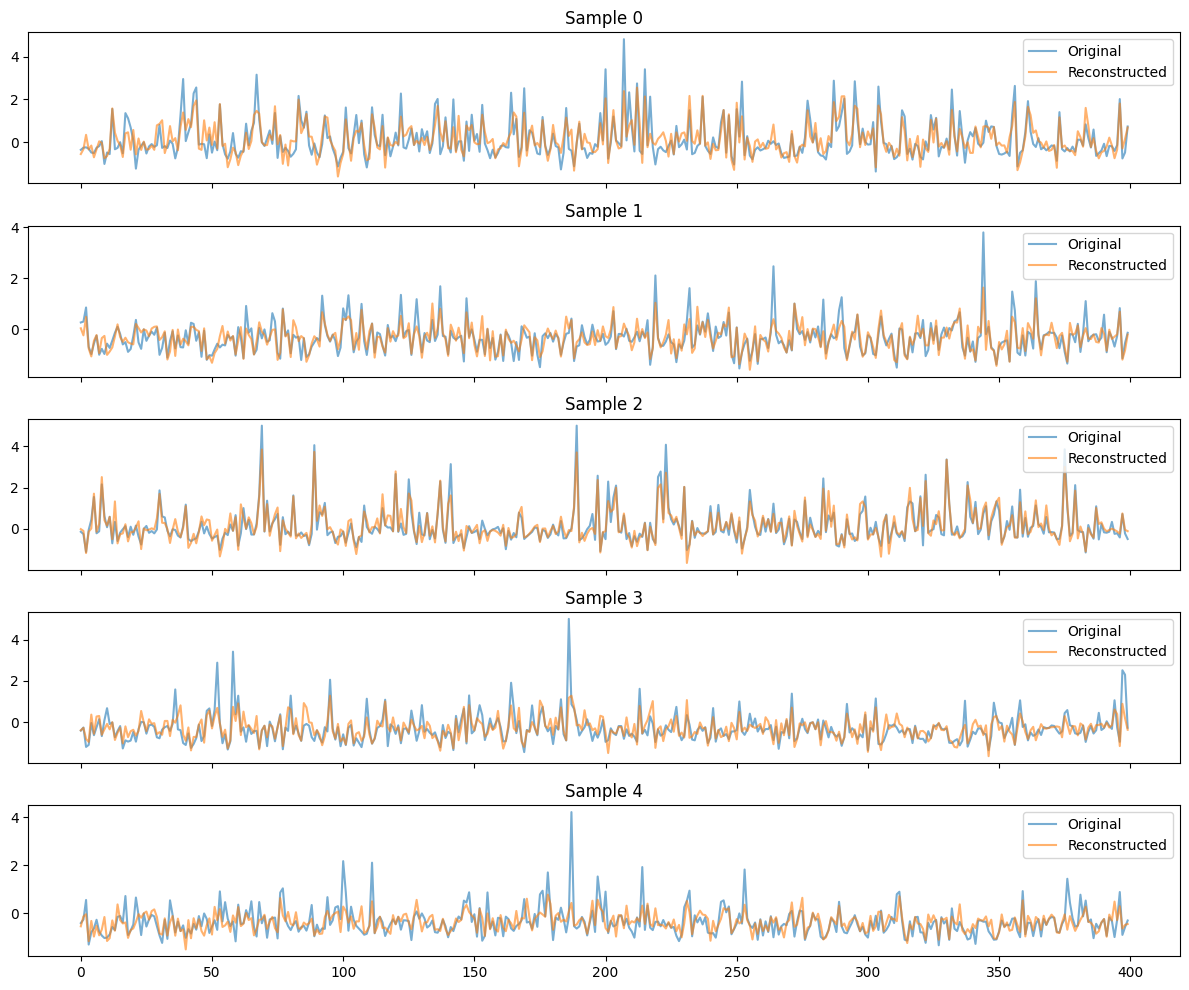

In [ ]:
z_loc = pyro.param("z_loc").detach().numpy()
print(z_loc.shape)
w_loc = pyro.param("w_loc").detach().numpy()
print(w_loc.shape)


X_recon = np.dot(z_loc, w_loc)
n_plot = 5
fig, axs = plt.subplots(n_plot, 1, figsize=(12, 2 * n_plot), sharex=True)


for i in range(n_plot):

    recon_error = ((X_train_tensor[i].numpy() - X_recon)**2).mean()
    print(f"Sample {i} reconstruction MSE: {recon_error:.4f}")
    
    axs[i].plot(X_train_tensor[i].numpy(), label="Original", alpha=0.6)
    axs[i].plot(X_recon[i], label="Reconstructed", alpha=0.6)
    axs[i].set_title(f"Sample {i}")
    axs[i].legend(loc="upper right")

plt.tight_layout()
plt.show()


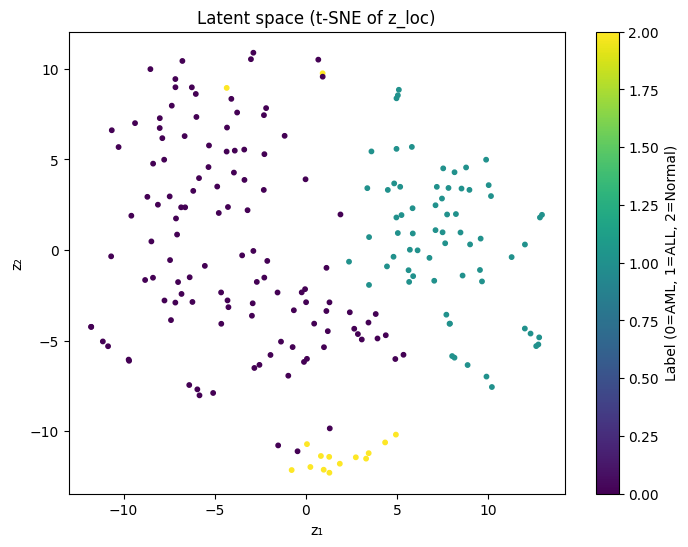

In [20]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
z_loc = pyro.param("z_loc").detach()  # shape: [n_samples, latent_dim]

z_tsne = TSNE(n_components=2).fit_transform(z_loc.cpu().numpy())

plt.figure(figsize=(8,6))
plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=test_label, cmap='viridis', s=10)
plt.title("Latent space (t-SNE of z_loc)")
plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
plt.xlabel("z₁")
plt.ylabel("z₂")
plt.show()


NOTE TO SELF:
- Looking at the two first components of the reduced gene space there are 3 clear clusters forming for the 3 different classes
- Use TSNE when: "I want a nice 2D map of my samples that reveals local structure — even if I can’t interpret the axes."
- Use z_loc plot when: "I want to visualize the latent space of my model, and I want to see how well the model is able to separate the classes."

Text(0.5, 1.0, 'Latent space (z_loc)')

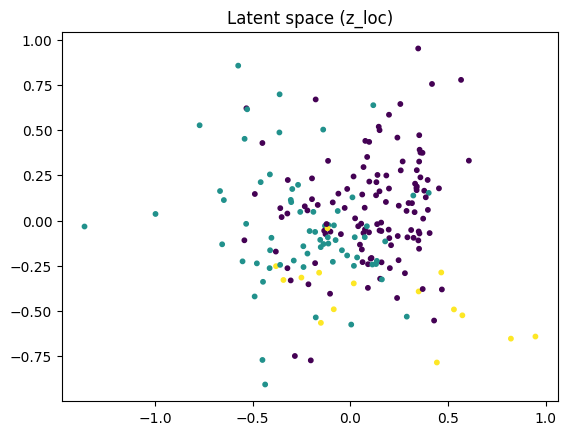

In [21]:
z_loc = pyro.param("z_loc").detach().numpy()

plt.scatter(z_loc[:, 0], z_loc[:, 1], c=test_label, cmap='viridis', s=10)
plt.title("Latent space (z_loc)")